# I. Install required packages

In [1]:
## The pip that are used in this project:
!pip install nba_api
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 7.5 MB/s  0:00:14 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] 1/2 [torchvision]


In [9]:
## The packages that are imported in this project:

# NBA API
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder, boxscoretraditionalv2

# General packages
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import seaborn as sns
import time
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F

# II. Sub function: Convert time format
Convert the player's playing time (a string in "mm:ss" format) to a floating point number of minutes, e.g. "12:30" → 12.5 minutes.
1. If the number is NaN, return 0.0
2. If the value is originally a number, convert it to a floating point number
3. Split the string "mm:ss" into two integers and convert to minutes:
12:30 → 12 + 30 / 60 → 12.5
4. If the string cannot be split correctly (e.g. malformed, empty string), return 0.0 conservatively.

In [3]:
# Time transformation
def parse_min(min_str):
    if pd.isnull(min_str):
        return 0.0 # if NaN, return 0.0
    if isinstance(min_str, (int, float)):
        return float(min_str) # dim it as a float.
    try:
        minutes, seconds = map(int, min_str.split(':'))
        return minutes + seconds / 60 # mm:ss to a float
    except:
        return 0.0

# III. Create heat maps to analyze the effectiveness of player cooperation
This process is for analyzing the effectiveness of player cooperation for a single team. The focus is on calculating the effectiveness of pairwise combinations based on the players' "simultaneous playing time" and "plus-minus performance" on the court, and finally using heatmap to visualize the results.

We use heatmaps as the input for CNN machine learning.

## 1. Provide weights for each team's match results
We set the weight based on the stage that each team reaches. Once a team reaches the round of 16, each of them will have a weight of one point, and each time you advance to the next round, your weight will be multiplied by two until you win the championship and get 16 points.

In [4]:
# Set weights based on match results
labels_by_season = {
        '2016-17': {
        'Golden State Warriors': 16,
        'Cleveland Cavaliers': 8,
        'San Antonio Spurs': 4,
        'Boston Celtics': 4,
        'Houston Rockets': 2,
        'Washington Wizards': 2,
        'Toronto Raptors': 2,
        'Utah Jazz': 2,
        'Chicago Bulls': 1,
        'Indiana Pacers': 1,
        'Milwaukee Bucks': 1,
        'Atlanta Hawks': 1,
        'Memphis Grizzlies': 1,
        'Oklahoma City Thunder': 1,
        'Portland Trail Blazers': 1,
        'Los Angeles Clippers': 1,
        'Miami Heat': 0,
        'Detroit Pistons': 0,
        'Charlotte Hornets': 0,
        'New York Knicks': 0,
        'Philadelphia 76ers': 0,
        'Orlando Magic': 0,
        'Brooklyn Nets': 0,
        'Denver Nuggets': 0,
        'New Orleans Pelicans': 0,
        'Dallas Mavericks': 0,
        'Sacramento Kings': 0,
        'Minnesota Timberwolves': 0,
        'Phoenix Suns': 0,
        'Los Angeles Lakers': 0
    },
    '2017-18': {
        'Golden State Warriors': 16,
        'Cleveland Cavaliers': 8,
        'Houston Rockets': 4,
        'Boston Celtics': 4,
        'Philadelphia 76ers': 2,
        'New Orleans Pelicans': 2,
        'Utah Jazz': 2,
        'Toronto Raptors': 2,
        'Indiana Pacers': 1,
        'Milwaukee Bucks': 1,
        'Miami Heat': 1,
        'Washington Wizards': 1,
        'Minnesota Timberwolves': 1,
        'Oklahoma City Thunder': 1,
        'Portland Trail Blazers': 1,
        'San Antonio Spurs': 1,
        'Detroit Pistons': 0,
        'Charlotte Hornets': 0,
        'New York Knicks': 0,
        'Brooklyn Nets': 0,
        'Chicago Bulls': 0,
        'Orlando Magic': 0,
        'Atlanta Hawks': 0,
        'Denver Nuggets': 0,
        'Los Angeles Clippers': 0,
        'Los Angeles Lakers': 0,
        'Sacramento Kings': 0,
        'Dallas Mavericks': 0,
        'Phoenix Suns': 0,
        'Memphis Grizzlies': 0
    },
    '2018-19': {
        'Toronto Raptors': 16,
        'Golden State Warriors': 8,
        'Milwaukee Bucks': 4,
        'Portland Trail Blazers': 4,
        'Philadelphia 76ers': 2,
        'Denver Nuggets': 2,
        'Houston Rockets': 2,
        'Boston Celtics': 2,
        'Brooklyn Nets': 1,
        'Indiana Pacers': 1,
        'Orlando Magic': 1,
        'Detroit Pistons': 1,
        'Los Angeles Clippers': 1,
        'Utah Jazz': 1,
        'Oklahoma City Thunder': 1,
        'San Antonio Spurs': 1,
        'Charlotte Hornets': 0,
        'Miami Heat': 0,
        'Washington Wizards': 0,
        'Atlanta Hawks': 0,
        'Chicago Bulls': 0,
        'New York Knicks': 0,
        'Cleveland Cavaliers': 0,
        'Sacramento Kings': 0,
        'Los Angeles Lakers': 0,
        'Minnesota Timberwolves': 0,
        'New Orleans Pelicans': 0,
        'Dallas Mavericks': 0,
        'Phoenix Suns': 0,
        'Memphis Grizzlies': 0
    },
    '2021-22': {
        'Golden State Warriors': 16,
        'Boston Celtics': 8,
        'Miami Heat': 4,
        'Dallas Mavericks': 4,
        'Milwaukee Bucks': 2,
        'Phoenix Suns': 2,
        'Memphis Grizzlies': 2,
        'Philadelphia 76ers': 2,
        'Toronto Raptors': 1,
        'Chicago Bulls': 1,
        'Minnesota Timberwolves': 1,
        'Denver Nuggets': 1,
        'Atlanta Hawks': 1,
        'Brooklyn Nets': 1,
        'New Orleans Pelicans': 1,
        'Utah Jazz': 1,
        'Charlotte Hornets': 0,
        'Cleveland Cavaliers': 0,
        'New York Knicks': 0,
        'Washington Wizards': 0,
        'Indiana Pacers': 0,
        'Orlando Magic': 0,
        'Detroit Pistons': 0,
        'Houston Rockets': 0,
        'Oklahoma City Thunder': 0,
        'Portland Trail Blazers': 0,
        'Los Angeles Lakers': 0,
        'Sacramento Kings': 0,
        'San Antonio Spurs': 0,
        'Los Angeles Clippers': 0
    },
    '2022-23': {
        'Denver Nuggets': 16,
        'Miami Heat': 8,
        'Los Angeles Lakers': 4,
        'Boston Celtics': 4,
        'Philadelphia 76ers': 2,
        'Phoenix Suns': 2,
        'New York Knicks': 2,
        'Golden State Warriors': 2,
        'Sacramento Kings': 1,
        'Cleveland Cavaliers': 1,
        'Brooklyn Nets': 1,
        'Atlanta Hawks': 1,
        'Minnesota Timberwolves': 1,
        'Milwaukee Bucks': 1,
        'Los Angeles Clippers': 1,
        'Chicago Bulls': 0,
        'Toronto Raptors': 0,
        'Washington Wizards': 0,
        'Indiana Pacers': 0,
        'Orlando Magic': 0,
        'Charlotte Hornets': 0,
        'Detroit Pistons': 0,
        'Houston Rockets': 0,
        'San Antonio Spurs': 0,
        'Portland Trail Blazers': 0,
        'Utah Jazz': 0,
        'New Orleans Pelicans': 0,
        'Oklahoma City Thunder': 0,
        'Dallas Mavericks': 0,
        'Memphis Grizzlies': 1
    },
    '2023-24': {
        'Boston Celtics': 16,
        'Dallas Mavericks': 8,
        'Indiana Pacers': 4,
        'Minnesota Timberwolves': 4,
        'New York Knicks': 2,
        'Cleveland Cavaliers': 2,
        'Oklahoma City Thunder': 2,
        'Denver Nuggets': 2,
        'Miami Heat': 1,
        'Philadelphia 76ers': 1,
        'Milwaukee Bucks': 1,
        'Orlando Magic': 1,
        'Los Angeles Clippers': 1,
        'Phoenix Suns': 1,
        'Los Angeles Lakers': 1,
        'New Orleans Pelicans': 1,
        'Golden State Warriors': 0,
        'Sacramento Kings': 0,
        'Chicago Bulls': 0,
        'Atlanta Hawks': 0,
        'Toronto Raptors': 0,
        'Brooklyn Nets': 0,
        'Charlotte Hornets': 0,
        'Detroit Pistons': 0,
        'Washington Wizards': 0,
        'Utah Jazz': 0,
        'Houston Rockets': 0,
        'Memphis Grizzlies': 0,
        'San Antonio Spurs': 0,
        'Portland Trail Blazers': 0
    }
}

## 2. Create heatmap

In [5]:
# ---------- 對所有球隊、所有球季批次產生 heatmap ----------

minutes_dir = "shared_minutes"
pm_dir = "shared_pm_per_min"
os.makedirs(minutes_dir, exist_ok=True)
os.makedirs(pm_dir, exist_ok=True)

nba_teams = teams.get_teams()

for season, team_labels in labels_by_season.items():
    season_tag = season.replace('-', '')

    for team_name in team_labels.keys():
        min_path = os.path.join(minutes_dir, f"{team_name.replace(' ', '_')}_{season_tag}_shared_minutes.png")
        pm_path = os.path.join(pm_dir, f"{team_name.replace(' ', '_')}_{season_tag}_shared_pm_per_min.png")

        # 如果這組圖片已經存在，就跳過（中斷後重跑不會重複抓取）
        if os.path.exists(min_path) and os.path.exists(pm_path):
            continue

        print(f"\n=== Processing {team_name} ({season}) ===")

        try:
            team_id = [t['id'] for t in nba_teams if t['full_name'] == team_name][0]

            gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=team_id, season_nullable=season)
            games = gamefinder.get_data_frames()[0]
            games = games[games['GAME_ID'].str.startswith('002')]
            game_ids = games['GAME_ID'].unique()

            player_game_data = []
            for game_id in tqdm(game_ids, desc=f"{team_name} {season}", unit="game"):
                try:
                    boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
                    stats = boxscore.player_stats.get_data_frame()
                    stats = stats[stats['TEAM_ID'] == team_id]
                    for _, row in stats.iterrows():
                        player_game_data.append({
                            'GAME_ID': game_id,
                            'PLAYER_NAME': row['PLAYER_NAME'],
                            'MIN': parse_min(row['MIN']),
                            'PLUS_MINUS': pd.to_numeric(row['PLUS_MINUS'], errors='coerce') if row['PLUS_MINUS'] is not None else 0.0
                        })
                    time.sleep(0.6)
                except Exception as e:
                    print(f"Error fetching game {game_id}: {e}")

            df_team = pd.DataFrame(player_game_data)
            df_team = df_team[df_team['MIN'] > 0]

            player_total_minutes = df_team.groupby('PLAYER_NAME')['MIN'].sum()
            eligible_players = player_total_minutes[player_total_minutes >= 820].index.tolist()

            pair_records = []
            for game_id in game_ids:
                game_df = df_team[df_team['GAME_ID'] == game_id]
                players = game_df['PLAYER_NAME'].unique()
                for p1, p2 in combinations(players, 2):
                    row1 = game_df[game_df['PLAYER_NAME'] == p1].iloc[0]
                    row2 = game_df[game_df['PLAYER_NAME'] == p2].iloc[0]
                    shared_minutes = min(row1['MIN'], row2['MIN'])
                    shared_pm = row1['PLUS_MINUS'] + row2['PLUS_MINUS']
                    pair_records.append({'P1': p1, 'P2': p2, 'SHARED_MIN': shared_minutes, 'SHARED_PM': shared_pm})

            all_players = sorted(set(eligible_players))
            if len(all_players) == 0:
                print(f"No eligible players for {team_name} {season}, skipped.")
                continue

            matrix_min = pd.DataFrame()
            matrix_pm_per_min = pd.DataFrame()
            for p1 in all_players:
                row_min, row_pm_per_min = [], []
                for p2 in all_players:
                    if p1 == p2:
                        row_min.append(None)
                        row_pm_per_min.append(None)
                        continue
                    match = [r for r in pair_records if (r['P1'] == p1 and r['P2'] == p2) or (r['P1'] == p2 and r['P2'] == p1)]
                    if match:
                        total_min = sum(m['SHARED_MIN'] for m in match)
                        total_pm = sum(m['SHARED_PM'] for m in match)
                        pm_per_min = total_pm / total_min if total_min > 0 else 0
                    else:
                        total_min = 0
                        pm_per_min = 0
                    row_min.append(total_min)
                    row_pm_per_min.append(pm_per_min)
                matrix_min[p1] = row_min
                matrix_pm_per_min[p1] = row_pm_per_min
            matrix_min.index = all_players
            matrix_pm_per_min.index = all_players

            plt.figure(figsize=(12, 10))
            sns.heatmap(matrix_min, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=2500, cbar_kws={'label': 'Minutes'}, square=True, annot_kws={'size': 7})
            plt.title(f"{team_name} - Shared Court Time (Minutes)", fontsize=16)
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(min_path)
            plt.close()

            plt.figure(figsize=(12, 10))
            sns.heatmap(matrix_pm_per_min, annot=True, fmt=".2f", cmap="RdBu", center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Plus-Minus per Minute'}, square=True, annot_kws={'size': 7})
            plt.title(f"{team_name} - Shared Plus-Minus per Minute", fontsize=16)
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(pm_path)
            plt.close()

        except Exception as e:
            print(f"Skipping {team_name} ({season}) due to error: {e}")
            continue

print("\nAll done!")


=== Processing Atlanta Hawks (2022-23) ===


Atlanta Hawks 2022-23:   0%|                                                                   | 0/82 [00:00<?, ?game/s]/var/folders/38/3hgln9rn0n195ct27h8d7c0c0000gn/T/ipykernel_2786/2781984909.py:34: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
Atlanta Hawks 2022-23: 100%|██████████████████████████████████████████████████████████| 82/82 [01:13<00:00,  1.11game/s]



=== Processing Minnesota Timberwolves (2022-23) ===


Minnesota Timberwolves 2022-23:   0%|                                                          | 0/82 [00:00<?, ?game/s]/var/folders/38/3hgln9rn0n195ct27h8d7c0c0000gn/T/ipykernel_2786/2781984909.py:34: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
Minnesota Timberwolves 2022-23: 100%|█████████████████████████████████████████████████| 82/82 [01:12<00:00,  1.13game/s]



=== Processing Milwaukee Bucks (2022-23) ===


...


=== Processing San Antonio Spurs (2023-24) ===


San Antonio Spurs 2023-24:   0%|                                                               | 0/82 [00:00<?, ?game/s]/var/folders/38/3hgln9rn0n195ct27h8d7c0c0000gn/T/ipykernel_2786/2781984909.py:34: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
San Antonio Spurs 2023-24: 100%|██████████████████████████████████████████████████████| 82/82 [01:12<00:00,  1.12game/s]



=== Processing Portland Trail Blazers (2023-24) ===


Portland Trail Blazers 2023-24:   0%|                                                          | 0/82 [00:00<?, ?game/s]/var/folders/38/3hgln9rn0n195ct27h8d7c0c0000gn/T/ipykernel_2786/2781984909.py:34: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
Portland Trail Blazers 2023-24: 100%|█████████████████████████████████████████████████| 82/82 [01:14<00:00,  1.09game/s]



All done!


## 3. Create a csv file to save teams' information
We transform a nested dictionary of playoff results into a flat, structured DataFrame where each row represents a team's performance in a given season. We then sort the data by season and playoff wins, and save the final table as a CSV file `labels.csv` for further analysis and modeling.

In [6]:
# Convert nested dictionaries to lists to create DataFrame
records = []
for season, team_labels in labels_by_season.items():
    for team_name, label in team_labels.items():
        records.append({'SEASON': season, 'TEAM_NAME': team_name, 'LABEL': label})

# Convert to pandas DataFrame
df = pd.DataFrame(records)

# Sort by SEASON and LABEL while the former is sort from largest to smallest
df = df.sort_values(by=['SEASON', 'LABEL'], ascending=[True, False])

# Save as CSV file
df.to_csv('labels.csv', index=False)
print("✅ The teams' information has been saved as 'labels.csv'.")

✅ The teams' information has been saved as 'labels.csv'.


# V. Machine Learning

## 1. Prepare materials for machine learning
We define a PyTorch dataset for a dual-image input model using NBA heatmap visualizations.

Steps:
1. Read label data from a CSV file
2. Load corresponding heatmap images (shared minutes and plus-minus per minute) for each team-season entry
3. Apply image transformations

In [10]:
## Data preparation

minutes_dir = "./shared_minutes"
pm_dir = "./shared_pm_per_min"
labels_path = "./labels.csv"
labels_df = pd.read_csv(labels_path)

class DualNBAImageDataset(Dataset):
    # store image directories, labels, and transform
    def __init__(self, image_dir1, image_dir2, labels_df, transform=None):
        self.image_dir1 = image_dir1
        self.image_dir2 = image_dir2
        self.labels_df = labels_df
        self.transform = transform

    # return number of samples (each sample = one team-season entry)
    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):

        # retrieve metadata from DataFrame
        team_name = self.labels_df.iloc[idx]['TEAM_NAME']
        season = self.labels_df.iloc[idx]['SEASON']
        label = self.labels_df.iloc[idx]['LABEL']

        # construct file base name, e.g., "Golden_State_Warriors_202223"
        base_name = f"{team_name.replace(' ', '_')}_{season.replace('-', '')}"

        # build full image paths for the two heatmaps
        img1_path = os.path.join(self.image_dir1, f"{base_name}_shared_minutes.png")
        img2_path = os.path.join(self.image_dir2, f"{base_name}_shared_pm_per_min.png")

        # load and convert images to RGB
        image1 = Image.open(img1_path).convert('RGB')
        image2 = Image.open(img2_path).convert('RGB')

        # apply transforms if specified (e.g., resizing, normalization)
        if self.transform:
            image1 = self.transform(image1)
            image2 = self.transform(image2)

        # return both images and the corresponding label as a tensor
        return image1, image2, torch.tensor(label, dtype=torch.float32)

## Image transformation

transform = transforms.Compose([
    transforms.Resize((224, 224)),                    # resize image to 224x224
    transforms.ToTensor(),                            # convert PIL image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # normalize using ImageNet mean/std
                         std=[0.229, 0.224, 0.225])
])

## 2. Split training and testing sets based on specific seasons
Before doing machine learning, we split the 2016 ~ 2024 data into training and test groups at a 2:1 ratio, and use the 2024 ~ 2025 regular season data as the prediction object

The result is a clean dataset ready for training deep learning models to predict playoff success based on visual team dynamics.

In [11]:
## Train-test split, 
# We splited the data into train set and test set to execute Machine Learning.
train_seasons = ['2016-17', '2017-18', '2018-19', '2021-22']
test_seasons = ['2022-23', '2023-24']
predicted_season = ['2024-25']

# split the label DataFrame by season
train_df = labels_df[labels_df['SEASON'].isin(train_seasons)]
test_df = labels_df[labels_df['SEASON'].isin(test_seasons)]

# create PyTorch datasets with the images and labels
train_data = DualNBAImageDataset(minutes_dir, pm_dir, train_df, transform=transform)
test_data = DualNBAImageDataset(minutes_dir, pm_dir, test_df, transform=transform)

## 3. Build the model
We use a dual-branch CNN architecture to process two different but complementary visual features:
* The first branch processes the heat map of players' **shared playing time** (measures the closeness of the appearance combination)
* The second branch processes the **plus-minus** heat map per minute (measures the effectiveness of the combination)

The outputs of the two are concatenated and integrated with the fully connected layer, and the prediction result is a continuous value label (number of playoff wins), which meets the requirements of the regression task.

Steps:
1. The DualCNN model uses two pretrained ResNet-18 branches to extract features from two input images.
2. It replaces each ResNet's final layer with nn.Identity() to get 512-dimensional feature vectors, which are concatenated into a 1024-dimensional vector.
3. The combined vector is passed through custom fully connected layers for prediction (e.g., binary classification).
4. The model uses Kaiming initialization and runs on GPU if available, otherwise defaults to CPU.

In [17]:
## Build the model

class DualCNN(nn.Module):
    def __init__(self):
        super(DualCNN, self).__init__()

        # use two separate ResNet-18 backbones to process two input modalities:
        self.branch1 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # shared minutes heatmap
        self.branch2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # plus-minus per minute heatmap

        # remove the final classification layer from each branch (keep as feature extractor)
        self.branch1.fc = nn.Identity()
        self.branch2.fc = nn.Identity()

        # fully connected head: combines features from both branches
        self.fc = nn.Sequential(
            nn.Linear(512 * 2, 256),   # 512 from each ResNet → concatenate → 1024
            nn.ReLU(),
            nn.Dropout(0.3),           # Prevent overfitting
            nn.Linear(256, 1)
        )

        self._initialize_weights() # custom weight initialization for fully connected layers

    def forward(self, x1, x2):
        # extract features from both input branches
        f1 = self.branch1(x1)  # from shared minutes heatmap
        f2 = self.branch2(x2)  # from plus-minus per minute heatmap

        # concatenate the two feature vectors
        combined = torch.cat((f1, f2), dim=1)

        # forward pass through classification head
        return self.fc(combined)

    def _initialize_weights(self):
        # kaiming initialization is used for better convergence with ReLU activations
        for m in self.fc:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

# instantiate model and move to appropriate device
model = DualCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DualCNN(
  (branch1): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, mom

## 4. Training
* The model is trained using MSE loss and the AdamW optimizer over up to 600 epochs.
* Training and evaluation are done using separate dataloaders, and losses are recorded each epoch.
* The best model (with lowest validation loss) is saved, and early stopping is triggered if no improvement occurs for 100 epochs.
* Training and evaluation steps include sending data to the proper device (CPU or GPU) and computing average losses.

In [18]:
# Training
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
EPOCHS = 600
early_stop_patience = 100

train_loader = DataLoader(train_data, batch_size=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=4, shuffle=False)

train_losses, test_losses = [], []
best_loss = float('inf')
patience_counter = 0

def train(model, loader):
    model.train()
    total_loss = 0
    for img1, img2, labels in tqdm(loader, desc="Training"):
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(img1, img2).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * img1.size(0)
    avg_loss = total_loss / len(loader.dataset)
    train_losses.append(avg_loss)
    print(f"Train Loss: {avg_loss:.4f}")

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for img1, img2, labels in tqdm(loader, desc="Evaluating"):
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            outputs = model(img1, img2).squeeze()
            loss = criterion(outputs, labels)
            total_loss += loss.item() * img1.size(0)
    avg_loss = total_loss / len(loader.dataset)
    test_losses.append(avg_loss)
    print(f"Test Loss: {avg_loss:.4f}")
    return avg_loss

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    train(model, train_loader)
    val_loss = evaluate(model, test_loader)
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_dual_model.pth')
        print("Saved Best Model")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print("Early stopping triggered")
            break


Epoch 1/600


Training: 100%|█████████████████████████████████████████████████████████████████████████| 30/30 [00:09<00:00,  3.13it/s]


Train Loss: 17.9587


Evaluating: 100%|███████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  6.38it/s]


Test Loss: 8.8731
Saved Best Model

Epoch 2/600


...

Test Loss: 7.9435

Epoch 146/600


Training: 100%|█████████████████████████████████████████████████████████████████████████| 30/30 [00:11<00:00,  2.63it/s]


Train Loss: 0.7577


Evaluating: 100%|███████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  5.25it/s]

Test Loss: 7.9831
Early stopping triggered


## 5. Save and visiualize data

Here we will output the names and championship probabilities of the 16 teams entering the playoffs, and save them as a CSV file.
We visualize the predicted probabilities by year, allowing users to select the year they are interested in. Additionally, since our model specifically focuses on identifying the championship-winning team, we highlight the predicted champion accordingly.


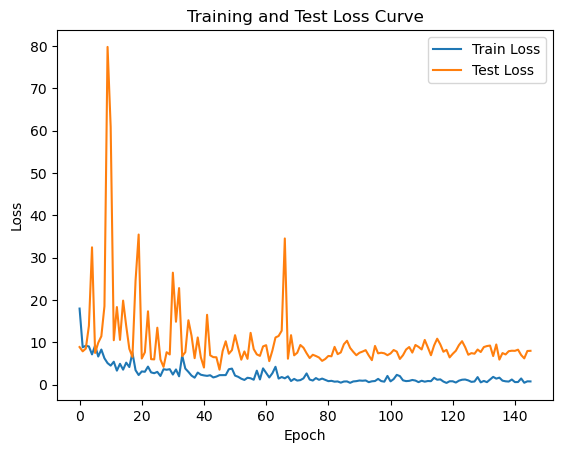

In [19]:
# Draw loss figure
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.show()

# Visualize probability
def visualize_past_season_predictions(season_str, playoff_teams, model, transform):
    df = labels_df[(labels_df['SEASON'] == season_str) & (labels_df['TEAM_NAME'].isin(playoff_teams))]
    dataset = DualNBAImageDataset(minutes_dir, pm_dir, df, transform=transform)

    model.eval()
    predictions = []
    for i in range(len(dataset)):
        img1, img2, _ = dataset[i]
        img1, img2 = img1.unsqueeze(0).to(device), img2.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img1, img2).item()
            predictions.append(pred)

    predictions = np.maximum(predictions, 0)
    exp_preds = np.exp(predictions - np.max(predictions))
    normalized_preds = exp_preds / np.sum(exp_preds)

    team_names = df['TEAM_NAME'].values
    team_probs = {team: prob for team, prob in zip(team_names, normalized_preds)}
    sorted_teams = sorted(team_probs.items(), key=lambda x: x[1], reverse=True)
    teams, probs = zip(*sorted_teams)

    # save as CSV
    save_df = pd.DataFrame({
        'Team': teams,
        'Predicted_Championship_Probability': probs
    })
    save_path = f"predicted_probs_{season_str.replace('-', '')}.csv"
    save_df.to_csv(save_path, index=False)
    print(f"Saved prediction results to {save_path}")

    plt.figure(figsize=(12, 8))
    plt.barh(teams, probs, color='lightgreen')
    plt.xlabel('Predicted Championship Probability')
    plt.title(f'Predicted Championship Probability for {season_str} Season')
    plt.gca().invert_yaxis()
    plt.show()

Saved prediction results to predicted_probs_202223.csv


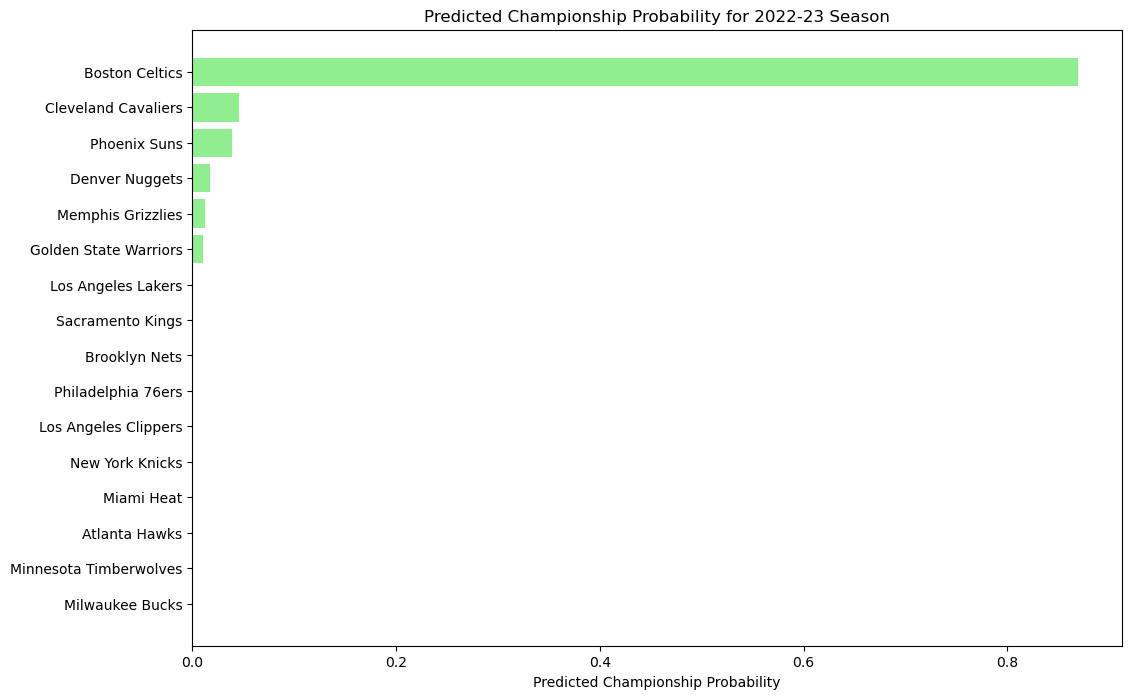

Saved prediction results to predicted_probs_202324.csv


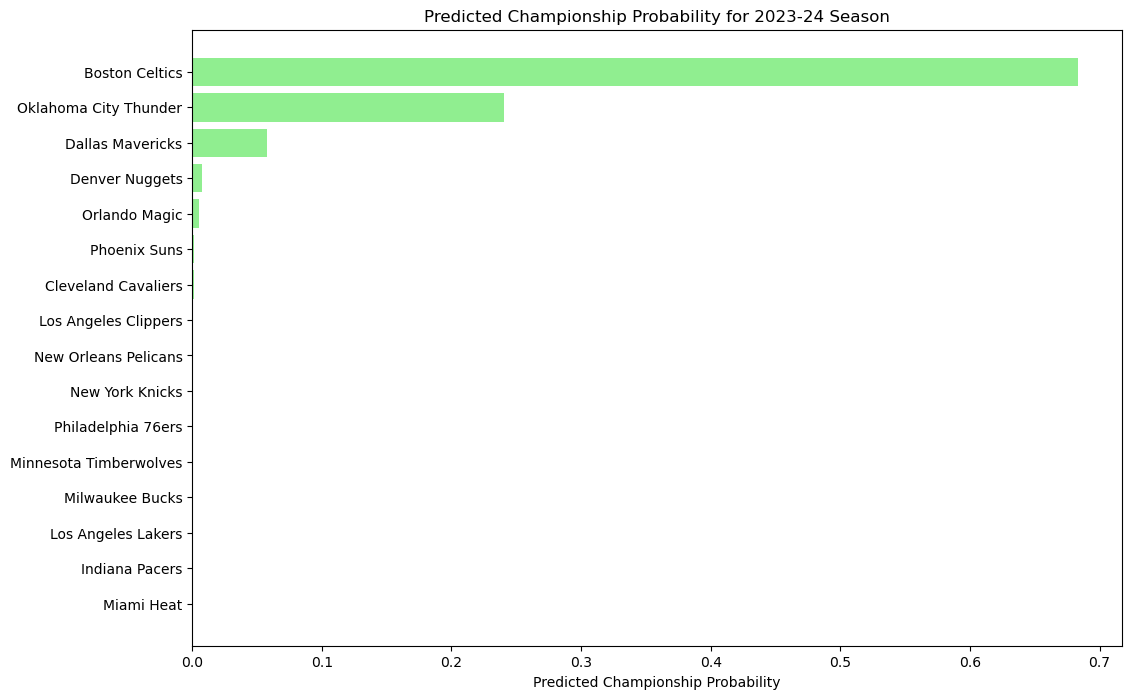

In [20]:
# Predicting 2022-23 and 2023-24
playoffs_22_23 = [
    'Milwaukee Bucks', 'Boston Celtics', 'Philadelphia 76ers', 'Cleveland Cavaliers',
    'New York Knicks', 'Brooklyn Nets', 'Atlanta Hawks', 'Miami Heat',
    'Denver Nuggets', 'Memphis Grizzlies', 'Sacramento Kings', 'Phoenix Suns',
    'Los Angeles Clippers', 'Golden State Warriors', 'Los Angeles Lakers', 'Minnesota Timberwolves'
]
playoffs_23_24 = [
    'Boston Celtics', 'New York Knicks', 'Cleveland Cavaliers', 'Indiana Pacers',
    'Orlando Magic', 'Miami Heat', 'Philadelphia 76ers', 'Milwaukee Bucks',
    'Oklahoma City Thunder', 'Denver Nuggets', 'Minnesota Timberwolves', 'Los Angeles Clippers',
    'Phoenix Suns', 'Dallas Mavericks', 'Los Angeles Lakers', 'New Orleans Pelicans'
]
visualize_past_season_predictions("2022-23", playoffs_22_23, model, transform)
visualize_past_season_predictions("2023-24", playoffs_23_24, model, transform)

In [21]:
df_202223 = pd.read_csv('predicted_probs_202223.csv')
df_202324 = pd.read_csv('predicted_probs_202324.csv')


df_202223.index = df_202223.index + 1
df_202324.index = df_202324.index + 1


df_map = {'2022-23': df_202223, '2023-24': df_202324}


year_dropdown = widgets.Dropdown(
    options=['2022-23', '2023-24'],
    value='2022-23',
    description='Select Season:',
    style={'description_width': 'initial'}
)


output = widgets.Output()


def update_display(change):
    with output:
        clear_output()
        selected_year = change['new']
        df = df_map[selected_year]

        print("Predicted Championship Probabilities:")
        display(df.style.set_caption(f"Season {selected_year}").set_table_styles(
            [{'selector': 'th', 'props': [('font-weight', 'bold')]}]
        ))

        plt.figure(figsize=(10, 6))

        max_prob_idx = df['Predicted_Championship_Probability'].idxmax()
        first_team = df.loc[max_prob_idx, 'Team']
        first_prob = df.loc[max_prob_idx, 'Predicted_Championship_Probability']


        bars = plt.bar(df['Team'], df['Predicted_Championship_Probability'], color='lightgray', alpha=0.3)

        bars[max_prob_idx - 1].set_color('gold')
        bars[max_prob_idx - 1].set_alpha(1.0)

        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Team')
        plt.ylabel('Predicted Championship Probability')
        plt.title(f'Predicted Championship Probabilities ({selected_year})')
        plt.tight_layout()
        plt.savefig('nba_prediction_chart.png')
        plt.show()


year_dropdown.observe(update_display, names='value')

display(year_dropdown)
display(output)

update_display({'new': '2022-23'})

Dropdown(description='Select Season:', options=('2022-23', '2023-24'), style=DescriptionStyle(description_widt…

Output()